## Objective

An agent learns to **store as few frames as possible** while still reconstructing a
multi-event sequence. It leverages the within-event autoregressive structure to *skip*
predictable frames and *store* at surprises. Keyframes should emerge at event onsets.

### Data
Stable features = event **identity** (constant-ish per event); autoreg features = within-event
trajectory (OU ramp toward 0 or 1). Variable event lengths. Boundaries come from cumulative
lengths, not fixed spacing.

In [11]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from utils import plot_style, norm01; plot_style('notebook');
from utils import generate_stim

def stim2tensor(stim): return torch.tensor(stim, dtype=torch.float32)

stim_dim = 10     # stim-vector dim
hidden_dim = 64   # hidden dim
recon_wt = 6.5    # weight on reconstruction (too high -> stores all; too low -> stores none)
LR = 1e-4
num_models = 3    # models to train (differ only in init seed); set 1 to reproduce single-model

# seeds
rng = np.random.default_rng(42)
seeds = rng.choice(1000, size=30, replace=False)
train_seeds, test_seeds, eval_seeds = seeds[:20].tolist(), seeds[20:25].tolist(), seeds[25:30].tolist()

# data
all_data = []
for s in seeds:
    stim_info = generate_stim(stim_dim=stim_dim, min_events=7, max_events=7, seed=s)
    all_data.append((stim2tensor(stim_info['stim']), stim_info['event_boundaries']))
train_data, test_data, eval_data = all_data[:20], all_data[20:25], all_data[25:30]
train_stims = [stim for stim, _ in train_data]
test_stims  = [stim for stim, _ in test_data]

one video shape (time, features): torch.Size([100, 10])
its boundaries : [ 0 12 25 41 58 73 85]


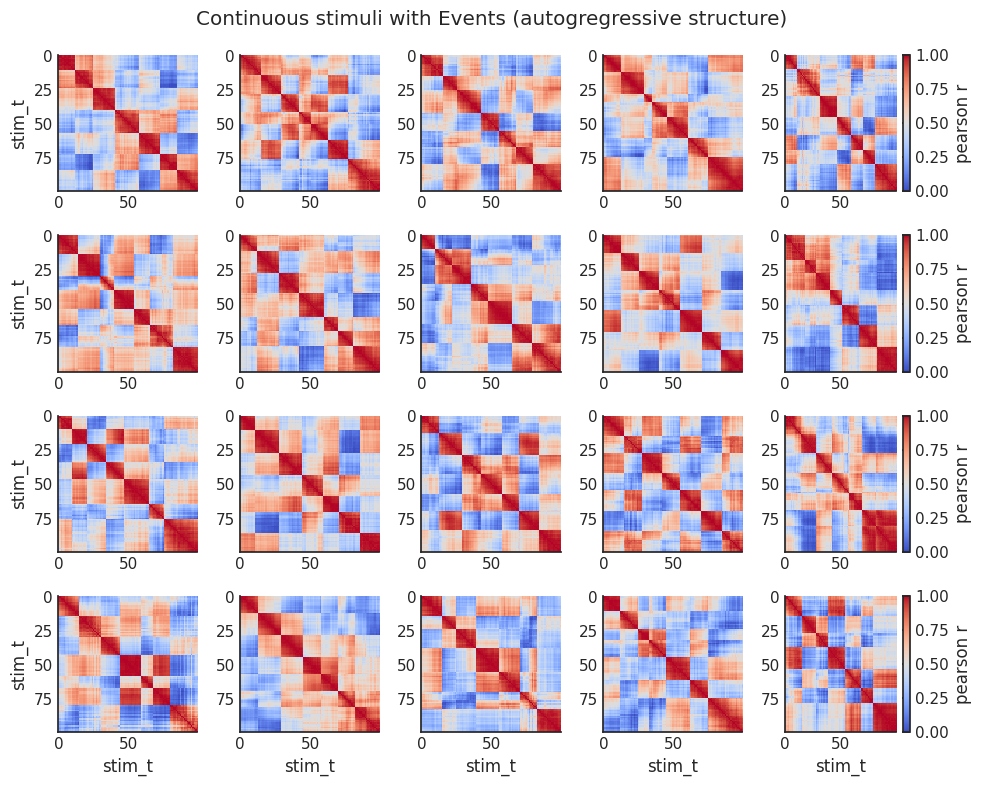

In [12]:
print("one video shape (time, features):", train_stims[0].shape)
print("its boundaries :", train_data[0][1])

fig, axs = plt.subplots(4, 5, figsize=(5*2, 4*2))
axs = axs.flatten()
plt.suptitle('Continuous stimuli with Events (autogregressive structure)')
for i, train_stim in enumerate(train_stims):
    axs[i].set(xlabel='stim_t' if i>14 else '', ylabel='stim_t' if i%5==0 else '' )
    im = axs[i].imshow(norm01(np.corrcoef(train_stim.numpy())), aspect='auto', cmap='coolwarm', vmin=0, vmax=1,
                   origin='upper', interpolation='nearest')
    if i in [4, 9, 14, 19]:    plt.colorbar(im, ax=axs[i], label='pearson r')
    plt.tight_layout()
plt.show()

### Forward walk
On **SKIP** the prediction feeds back in (true autoregressive rollout); on **STORE** the
real frame does, resetting drift. Straight-through Gumbel makes the discrete choice trainable.

In [13]:
def forward_walk(stim, predictor, keyframer, tau=1.0):
    stim_len = stim.shape[0]
    hidden_feats = torch.zeros(hidden_dim)   # GRU hidden state, reset each video
    reconstruction, binarized_keyframes = [], []
    memory_mass = 0.0                         # accumulates soft store decisions for loss

    # initialize first recon_stim and correspond embedding
    recon_stim_t = stim[0]
    _, hidden_feats = predictor.step(recon_stim_t, hidden_feats)
    reconstruction.append(recon_stim_t)

    for t in range(1, stim_len):

        # PREDICT
        # GRU: (x,h) -> h_new
        # Linear: (x,h_new) -> x_new
        y_true = stim[t]
        y_pred, hidden_feats = predictor.step(recon_stim_t, hidden_feats)
        error = F.mse_loss(y_pred, y_true).detach() # should spike at boundaries

        # KEYFRAME DECISION
        logits = keyframer(y_true, y_pred, error)

        # hard=True keep it discrete for forward pass, while
        #       straight-through simultaneously keeps it continuous for backward pass
        # tau anneals from soft (~0/1) to hard (exactly 0/1) over training
        # gate: vector with [skip, store] probabilities, binarized here bc hard=True
        gate = F.gumbel_softmax(logits, tau=tau, hard=True)
        store = gate[1]

        # UPDATE
        # store is a continuous value here (for gradient flow) but will be 0 or 1 in the forward pass
        recon_stim_t = (store * y_true)   +   ((1 - store) * y_pred)
        reconstruction.append(recon_stim_t)
        memory_mass = memory_mass + store
        binarized_keyframes.append(store.detach().item())

    reconstruction = torch.stack(reconstruction)
    recon_err = F.mse_loss(reconstruction, stim)
    normed_memory_mass = memory_mass / stim_len
    loss = normed_memory_mass + (recon_wt * recon_err) # the thing to minimize
    return reconstruction, recon_err, memory_mass, binarized_keyframes, loss

### Model: predictor + keyframer

In [14]:
class Predictor(nn.Module):
    """Given a running hidden state, predict the next frame."""
    def __init__(self):
        super().__init__() 
        self.rnn = nn.GRUCell(stim_dim, hidden_dim) # outputs new hidden state
        self.out = nn.Linear(hidden_dim, stim_dim) # outputs predicted next frame
        
    def step(self, x, h):          # one autoregressive step
        h = self.rnn(x, h)
        return self.out(h), h # return predicted next frame, new hidden state


class Keyframer(nn.Module):
    """Decide STORE vs SKIP from (actual, predicted, drift)."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential( # run in this order
            nn.Linear(2 * stim_dim + 1, hidden_dim), # actual*predicted + drift=1
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)          # logits: [skip, store]
        )

    def forward(self, actual, pred, drift):
        feat = torch.cat([actual, pred, drift.unsqueeze(0)], dim=-1)
        return self.net(feat)

### Train

In [15]:
EPOCHS = 50
all_model_learning, trained_models = [], []

for model_idx in range(num_models):
    torch.manual_seed(1000 + model_idx)   # different init per model; data stays identical across models
    predictor, keyframer = Predictor(), Keyframer()
    opt = torch.optim.Adam(list(predictor.parameters()) + list(keyframer.parameters()), lr=LR)

    # generate test stims once
    test_data = []
    for s in test_seeds:
        stim_info = generate_stim(stim_dim=stim_dim, seed=s)
        test_data.append((stim2tensor(stim_info['stim']), stim_info["event_boundaries"]))
    test_stims = [stim for stim, _ in test_data]

    model_learning = {"epoch": [], "train_recon_err": [], "train_memory_mass": [], "train_loss": [],
                                   "test_recon_err": [], "test_memory_mass": [], "test_loss": []}

    for epoch in range(EPOCHS):
        epoch_recon_err = epoch_memory_mass = epoch_binarized_keyframes = epoch_loss = 0.0

        tau = max(0.5, 0.95 ** epoch)            # anneal: soft (~0/1) -> sharp (exactly 0/1)

        for stim in train_stims:
            # forward pass
            reconstruction, recon_err, memory_mass, binarized_keyframes, loss =\
                forward_walk(stim, predictor, keyframer, tau=tau)
            # clear old gradients, backprop, and update weights
            opt.zero_grad(); loss.backward(); opt.step()
            # increment across stims
            # epoch_reconstruction += reconstruction.item()
            epoch_recon_err += recon_err.item()
            epoch_memory_mass += memory_mass.item()
            epoch_binarized_keyframes = binarized_keyframes
            epoch_loss += loss.item()

        # append epoch results
        model_learning["epoch"].append(epoch)
        model_learning["train_recon_err"].append(epoch_recon_err/len(train_stims))
        model_learning["train_memory_mass"].append(epoch_memory_mass/len(train_stims))
        model_learning["train_loss"].append(epoch_loss/len(train_stims))

        # evaluate on all test stims (no gradient)
        with torch.no_grad():
            test_recon, test_mass, test_loss = [], [], []
            for ts in test_stims:
                reconstruction, recon_err, memory_mass, binarized_keyframes, loss =\
                    forward_walk(ts, predictor, keyframer, tau=tau)
                test_recon.append(recon_err.item())
                test_mass.append(memory_mass.item())
                test_loss.append(loss.item())
        model_learning["test_recon_err"].append(np.mean(test_recon))
        model_learning["test_memory_mass"].append(np.mean(test_mass))
        model_learning["test_loss"].append(np.mean(test_loss))

    df = pd.DataFrame(model_learning)
    assert len(df) == EPOCHS, f"Expected {EPOCHS} epochs, got {len(df)}"
    df["model_idx"] = model_idx
    all_model_learning.append(df)
    trained_models.append((predictor, keyframer))

model_learning_df = pd.concat(all_model_learning, ignore_index=True)
model_learning_df.head()

,epoch,train_recon_err,train_memory_mass,train_loss,test_recon_err,test_memory_mass,test_loss,model_idx
0,0,0.147897,53.30,1.494329,0.130057,56.2,1.407374,0
1,1,0.135209,53.45,1.413355,0.118475,56.2,1.332085,0
2,2,0.108097,57.40,1.276629,0.101294,57.2,1.230410,0
3,3,0.097253,57.30,1.205144,0.088715,58.6,1.162646,0
4,4,0.079714,59.15,1.109641,0.066079,61.6,1.045515,0


### Learning

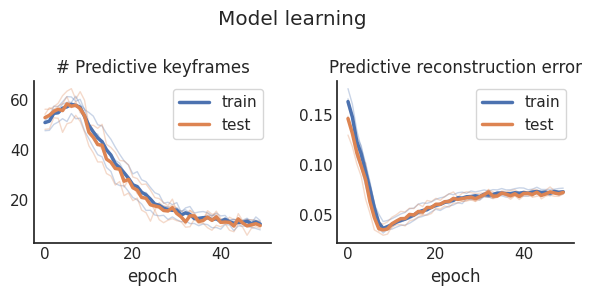

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
plt.suptitle('Model learning')

metrics = [("memory_mass", "# Predictive keyframes"), ("recon_err", "Predictive reconstruction error")]
mean_df = model_learning_df.groupby("epoch").mean(numeric_only=True)   # avg across models

for a, (metric, title) in zip(ax, metrics):
    # thin faint line per model (train=blue, test=orange)
    for _, g in model_learning_df.groupby("model_idx"):
        a.plot(g["epoch"], g[f"train_{metric}"], color="C0", alpha=0.3, lw=1)
        a.plot(g["epoch"], g[f"test_{metric}"],  color="C1", alpha=0.3, lw=1)
    # bold mean across models
    a.plot(mean_df.index, mean_df[f"train_{metric}"], color="C0", lw=2.5, label='train')
    a.plot(mean_df.index, mean_df[f"test_{metric}"],  color="C1", lw=2.5, label='test')
    a.set(title=title, xlabel='epoch'); a.legend()

plt.tight_layout(); plt.show()

### Evaluation

In [17]:
eval_results = []
for model_idx, (predictor, keyframer) in enumerate(trained_models):
    with torch.no_grad():
        for stim_t, boundaries in eval_data:
            # binarized_keyframes = 0/1 per timestep
            _, _, _, binarized_keyframes, _, = forward_walk(stim_t, predictor, keyframer, tau=0.5)
            # prepend 0
            binarized_keyframes = [0] + [i + 1 for i, key in enumerate(binarized_keyframes) if key > 0.5]
            eval_results.append((model_idx, stim_t, boundaries, binarized_keyframes))

eval_results_df = pd.DataFrame(eval_results, columns=["model_idx", "stim", "boundaries", "binarized_keyframes"])
eval_results_df.head()

,model_idx,stim,boundaries,binarized_keyframes
0,0,"[[tensor(0.5396), tensor(0.2854), tensor(0.519...","[0, 15, 27, 38, 50, 65, 84]","[0, 16, 23, 31, 32, 33, 45, 48, 60, 77, 82, 86]"
1,0,"[[tensor(0.8538), tensor(0.8733), tensor(0.603...","[0, 13, 26, 38, 55, 66, 85]","[0, 7, 27, 40, 42, 47, 48, 54, 80, 81, 89, 95]"
2,0,"[[tensor(0.9702), tensor(0.6847), tensor(0.849...","[0, 16, 27, 46, 56, 69, 81]","[0, 14, 26, 27, 28, 41, 55]"
3,0,"[[tensor(0.3242), tensor(0.4230), tensor(0.486...","[0, 16, 28, 43, 55, 73, 83]","[0, 1, 4, 9, 39, 40, 45, 50, 61, 63, 84, 86, 9..."
4,0,"[[tensor(0.1652), tensor(0.8305), tensor(0.211...","[0, 13, 26, 41, 54, 67, 84]","[0, 9, 32, 62, 73, 84, 92, 96]"


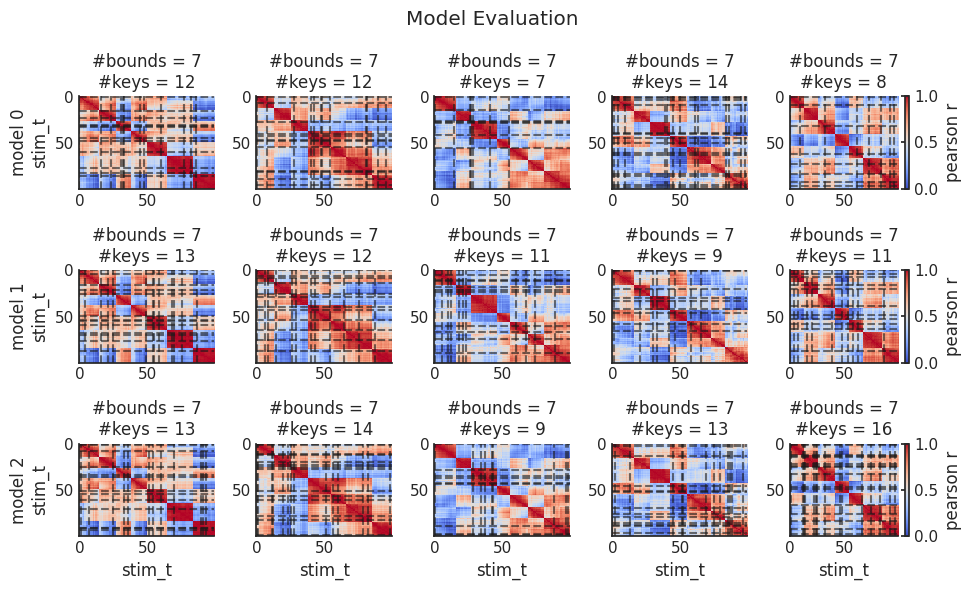

In [21]:
n_stim = len(eval_data)   # one row per model, n_stim per row
fig, axes = plt.subplots(num_models, n_stim, figsize=(n_stim*2, num_models*2), squeeze=False)
plt.suptitle('Model Evaluation')

for i, (model_idx, stim_t, boundaries, keyframes) in enumerate(eval_results):
    ax = axes[i // n_stim, i % n_stim]

    ax.set(title=f"#bounds = {len(boundaries)}\n#keys = {len(keyframes)}",
           xlabel="stim_t" if i // n_stim == num_models - 1 else '',
           ylabel=f"model {model_idx}\nstim_t" if i % n_stim == 0 else '')
    im = ax.imshow(norm01(np.corrcoef(stim_t.numpy())), aspect='auto', cmap='coolwarm',
                   vmin=0, vmax=1, origin='upper', interpolation='nearest')
    for kf in keyframes:
        ax.axvline(kf, color="k", linestyle="--", alpha=0.6)
        ax.axhline(kf, color="k", linestyle="--", alpha=0.6)

    if i % n_stim == n_stim - 1:     plt.colorbar(im, ax=ax, label="pearson r")

plt.tight_layout(); plt.show()

/home/nuttidalab/miniconda3/envs/narrative_map/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/nuttidalab/miniconda3/envs/narrative_map/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_1983711/2007311254.py:10: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(n_bounds, n_keys, 1)


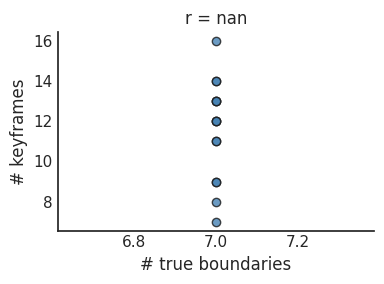

In [19]:
n_bounds = [len(boundaries) for _, _, boundaries, _ in eval_results]
n_keys   = [len(keyframes)  for _, _, _, keyframes  in eval_results]

fig, ax = plt.subplots(figsize=(4, 3))
r = np.corrcoef(n_bounds, n_keys)[0, 1]
ax.set(title=f"r = {r:.2f}", xlabel="# true boundaries", ylabel="# keyframes")
ax.scatter(n_bounds, n_keys, color='steelblue', edgecolors='k', alpha=0.8)

# regression line
m, b = np.polyfit(n_bounds, n_keys, 1)
x_range = np.linspace(min(n_bounds), max(n_bounds), 100)
ax.plot(x_range, m * x_range + b, color='k', linestyle='--', linewidth=1)

plt.tight_layout(); plt.show()

### Jaccard's/Hamming test

In [20]:
def overlap_per_tolerance(boundaries, keyframes, T, tol):
    """Dilate both sets by ±tol frames, then compute Jaccard |B∩K|/|B∪K| and Hamming distance."""
    bound_mask, key_mask = np.zeros(T, dtype=bool), np.zeros(T, dtype=bool)
    # dilate
    for b in boundaries:    bound_mask[max(0, b - tol):min(T, b + tol + 1)] = True
    for k in keyframes:     key_mask[max(0, k - tol):min(T, k + tol + 1)] = True
    intersection, union = (bound_mask & key_mask).sum(), (bound_mask | key_mask).sum()
    jaccard = intersection / union if union > 0 else 0.0
    hamming = (bound_mask != key_mask).sum()
    return jaccard, hamming

N_PERM = 1000
tolerances = [0, 1, 2, 3, 4, 5, 6]
model_ids = sorted(eval_results_df["model_idx"].unique())

# run the full test per model, collect observed + null (one entry per model), then average across models
np.random.seed(42)
obs_j  = {tol: [] for tol in tolerances}   # per-model observed Jaccard (avg over its eval stims)
obs_h  = {tol: [] for tol in tolerances}
null_j = {tol: [] for tol in tolerances}   # per-model null draws (each a length-N_PERM list)
null_h = {tol: [] for tol in tolerances}

for m in model_ids:
    g = eval_results_df[eval_results_df["model_idx"] == m]
    # metrics need only (boundaries, keyframes, sequence-length T); the stim tensor isn't used here
    bound_key_data = [(bounds, keys, stim_t.shape[0])
                      for stim_t, bounds, keys in zip(g["stim"], g["boundaries"], g["binarized_keyframes"])]

    # observed (per tolerance, averaged across this model's eval stims)
    for tol in tolerances:
        obs = [overlap_per_tolerance(bounds, keys, T, tol) for bounds, keys, T in bound_key_data]
        obs_j[tol].append(np.mean([o[0] for o in obs]))
        obs_h[tol].append(np.mean([o[1] for o in obs]))

    # permutation null for this model (one null loop: same random draw feeds both metrics)
    perm_jaccards = {tol: [] for tol in tolerances}
    perm_hammings = {tol: [] for tol in tolerances}
    for _ in range(N_PERM):
        for tol in tolerances:
            js, hs = [], []
            for bounds, keys, T in bound_key_data:
                # prepend key=0 so as to not inflate results
                permuted_keys = np.concatenate([[0], np.random.choice(np.arange(1, T), size=len(keys) - 1, replace=False)])
                j, h = overlap_per_tolerance(bounds, permuted_keys, T, tol)
                js.append(j); hs.append(h)
            perm_jaccards[tol].append(np.mean(js))
            perm_hammings[tol].append(np.mean(hs))
    for tol in tolerances:
        null_j[tol].append(perm_jaccards[tol])
        null_h[tol].append(perm_hammings[tol])

print(f"n models = {len(model_ids)}, n eval stims/model = {len(bound_key_data)}")
print(f"{'tolerance':>9}  {'Jaccard':>8} {'null':>7} {'p':>6}    {'Hamming':>8} {'null':>7} {'p':>6}")
print("-" * 60)
for tol in tolerances:
    j = np.mean(obs_j[tol]); h = np.mean(obs_h[tol])         # observed, averaged across models
    jn = np.mean(np.array(null_j[tol]), axis=0)              # null, averaged across models -> len N_PERM
    hn = np.mean(np.array(null_h[tol]), axis=0)
    # J: higher = more overlap; H: lower = closer
    print(f"{tol:>9}  {j:>8.3f} {jn.mean():>7.3f} {(jn >= j).mean():>6.3f}"
          f"    {h:>8.3f} {hn.mean():>7.3f} {(hn <= h).mean():>6.3f}")

n models = 3, n eval stims/model = 5
tolerance   Jaccard    null      p     Hamming    null      p
------------------------------------------------------------
        0     0.077   0.100  0.979      16.067  15.299  0.993
        1     0.158   0.170  0.764      36.600  35.891  0.727
        2     0.253   0.262  0.680      46.667  45.852  0.687
        3     0.358   0.361  0.564      48.533  48.292  0.533
        4     0.463   0.470  0.626      45.667  45.070  0.611
        5     0.573   0.583  0.690      39.200  38.189  0.691
        6     0.668   0.684  0.773      31.733  30.088  0.781


### ToDo


* vary n_events, n_models